In [1]:
import os
import io
import gzip
import json
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.patches as mpatches

from dotenv import load_dotenv
from google.cloud import storage

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde


In [2]:
# load combined data

df = pd.read_csv("/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ft_all_pfam_sp.csv.gz")

In [3]:
df.head()

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
0,PF00010,Q7Z6G8_PF00536_812,Q7Z6G8,False,1143,0.257597,8.820103e-19,0.787307,6.918559e-242,0.529710,PF00536
1,PF11722,Q9NUP7_PF11722_18,Q9NUP7,True,439,0.026799,5.754848e-01,0.539265,1.734913e-34,0.512467,PF11722
2,PF00010,Q8WU90_PF18044_104,Q8WU90,False,397,0.166906,8.422100e-04,0.626052,1.362520e-44,0.459146,PF18044
3,PF00569,Q9Y4J8_PF00569_235,Q9Y4J8,True,1119,0.188510,2.071464e-10,0.629437,1.623944e-124,0.440927,PF00569
4,PF02209,P09327_PF02209_793,P09327,True,632,0.186976,2.212267e-06,0.618647,5.136239e-68,0.431671,PF02209


In [4]:
# counting domains in pfams

pfam_counts = (
    df[df['model']=='all_pfams']['pfam']
    .value_counts()
    .reset_index()
)

pfam_counts.columns = ['pfam', 'count']

In [8]:
pfam_counts.head(30)

,pfam,count
0,PF00046,37
1,PF00096,36
2,PF00018,36
3,PF00595,31
4,PF00397,26
5,PF00505,17
6,PF00249,15
7,PF02037,14
8,PF00157,12
9,PF01846,12


In [9]:
model_valid = list(pfam_counts[pfam_counts['count'] > 4]['pfam'])
# model_valid.append('all_pfams')

In [10]:
df_valid = df[df['pfam'].isin(model_valid)]

In [11]:
df_valid.head()

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
0,PF00010,Q7Z6G8_PF00536_812,Q7Z6G8,False,1143,0.257597,8.820103e-19,0.787307,6.918559e-242,0.529710,PF00536
8,PF06467,Q9UJ78_PF06467_334,Q9UJ78,True,678,0.186368,1.025662e-06,0.587158,4.585924e-64,0.400790,PF06467
11,PF00010,P22681_PF00627_854,P22681,False,850,0.235321,3.693812e-12,0.618500,7.292570e-91,0.383179,PF00627
18,PF00010,Q15365_PF00013_278,Q15365,False,1360,0.370119,2.091066e-45,0.711415,2.862550e-210,0.341296,PF00013
20,PF00010,Q9UJ78_PF06467_334,Q9UJ78,False,678,0.186368,1.025662e-06,0.517991,8.172506e-48,0.331623,PF06467


In [12]:
df_doms = pd.read_csv("/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ft_all_doms_sp.csv.gz")
# df_doms.to_csv("/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ft_all_doms_sp.csv.gz", index=False, compression='gzip')

In [13]:
df_doms.head()

,model_domain,target_domain,model_pfam,target_pfam,same_pfam,is_self,ft_rho_test,ft_rho_full,baseline_rho_test,baseline_rho_full,delta_rho_test,delta_rho_full,delta_rho
0,A0PJY2_PF00096_289,A0PJY2_PF00096_289,PF00096,PF00096,True,True,0.304414,0.362050,0.247891,0.276918,0.056523,0.085132,0.056523
1,A0PJY2_PF00096_289,A1X283_PF00018_155,PF00096,PF00018,False,False,0.488040,0.514951,0.498734,0.525018,-0.010694,-0.010067,-0.010067
2,A0PJY2_PF00096_289,A1X283_PF00018_222,PF00096,PF00018,False,False,0.435782,0.392745,0.453662,0.409388,-0.017881,-0.016643,-0.016643
3,A0PJY2_PF00096_289,A6NK59_PF07525_532,PF00096,PF07525,False,False,0.139828,0.170460,0.135431,0.165628,0.004397,0.004831,0.004831
4,A0PJY2_PF00096_289,O00308_PF00397_440,PF00096,PF00397,False,False,0.712059,0.693012,0.711619,0.692651,0.000441,0.000361,0.000361


In [14]:
df_same = df_doms[df_doms["same_pfam"] == True]

In [15]:
agg = (
    df_same.groupby(["model_pfam", "model_domain"])
    .agg(
        median_ft_rho=("ft_rho_full", "median"),
        n=("ft_rho_full", "size")
    )
    .reset_index()
)

In [16]:
best_per_pfam = agg.loc[
    agg.groupby("model_pfam")["median_ft_rho"].idxmax()
].reset_index(drop=True)

In [17]:
best_per_pfam.head()

,model_pfam,model_domain,median_ft_rho,n
0,PF00010,Q05195_PF00010_58,0.413826,2
1,PF00013,Q96AE4_PF00013_98,0.677280,9
2,PF00018,A1X283_PF00018_222,0.644807,36
3,PF00030,P07315_PF00030_91,0.482858,12
4,PF00035,P78563_PF00035_80,0.668719,2


In [18]:
worst_per_pfam = agg.loc[
    agg.groupby("model_pfam")["median_ft_rho"].idxmin()
].reset_index(drop=True)

In [19]:
worst_per_pfam.head()

,model_pfam,model_domain,median_ft_rho,n
0,PF00010,P50539_PF00010_70,0.401445,2
1,PF00013,Q5U5Q3_PF00013_325,0.423959,9
2,PF00018,O15259_PF00018_152,0.542900,36
3,PF00030,P07320_PF00030_90,0.374005,12
4,PF00035,O95793_PF00035_183,0.633417,2


In [20]:
best_per_pfam_list = list(best_per_pfam['model_domain'])
worst_per_pfam_list = list(worst_per_pfam['model_domain'])

# Boxplots

In [21]:
df_best_worst = df_same[df_same['model_domain'].isin(best_per_pfam_list + worst_per_pfam_list)]

In [22]:
df_best_worst

,model_domain,target_domain,model_pfam,target_pfam,same_pfam,is_self,ft_rho_test,ft_rho_full,baseline_rho_test,baseline_rho_full,delta_rho_test,delta_rho_full,delta_rho
1031,A1X283_PF00018_222,A1X283_PF00018_155,PF00018,PF00018,True,False,0.539055,0.568788,0.498734,0.525018,0.040321,0.043770,0.043770
1032,A1X283_PF00018_222,A1X283_PF00018_222,PF00018,PF00018,True,True,0.598131,0.650087,0.453662,0.409388,0.144469,0.240700,0.144469
1049,A1X283_PF00018_222,O15259_PF00018_152,PF00018,PF00018,True,False,0.411486,0.436424,0.290399,0.294717,0.121087,0.141708,0.141708
1059,A1X283_PF00018_222,O43295_PF00018_745,PF00018,PF00018,True,False,0.658624,0.646759,0.605646,0.583822,0.052978,0.062937,0.062937
1063,A1X283_PF00018_222,O43586_PF00018_361,PF00018,PF00018,True,False,0.659806,0.691469,0.616270,0.612592,0.043536,0.078878,0.078878
...,...,...,...,...,...,...,...,...,...,...,...,...,...
263677,Q9Y618_PF00249_613,Q9Y618_PF00249_613,PF00249,PF00249,True,True,0.104205,0.135344,0.259509,0.265677,-0.155304,-0.130334,-0.155304
264709,Q9Y6V0_PF05715_1058,Q9Y6V0_PF05715_1058,PF05715,PF05715,True,True,0.584861,0.566163,0.328462,0.284076,0.256399,0.282087,0.256399
264751,P02640_PF02209_762,O75366_PF02209_785,PF02209,PF02209,True,False,0.305803,0.363079,0.147516,0.214390,0.158287,0.148689,0.148689
264798,P02640_PF02209_762,P02640_PF02209_762,PF02209,PF02209,True,True,0.715922,0.734059,0.572988,0.563443,0.142934,0.170616,0.142934


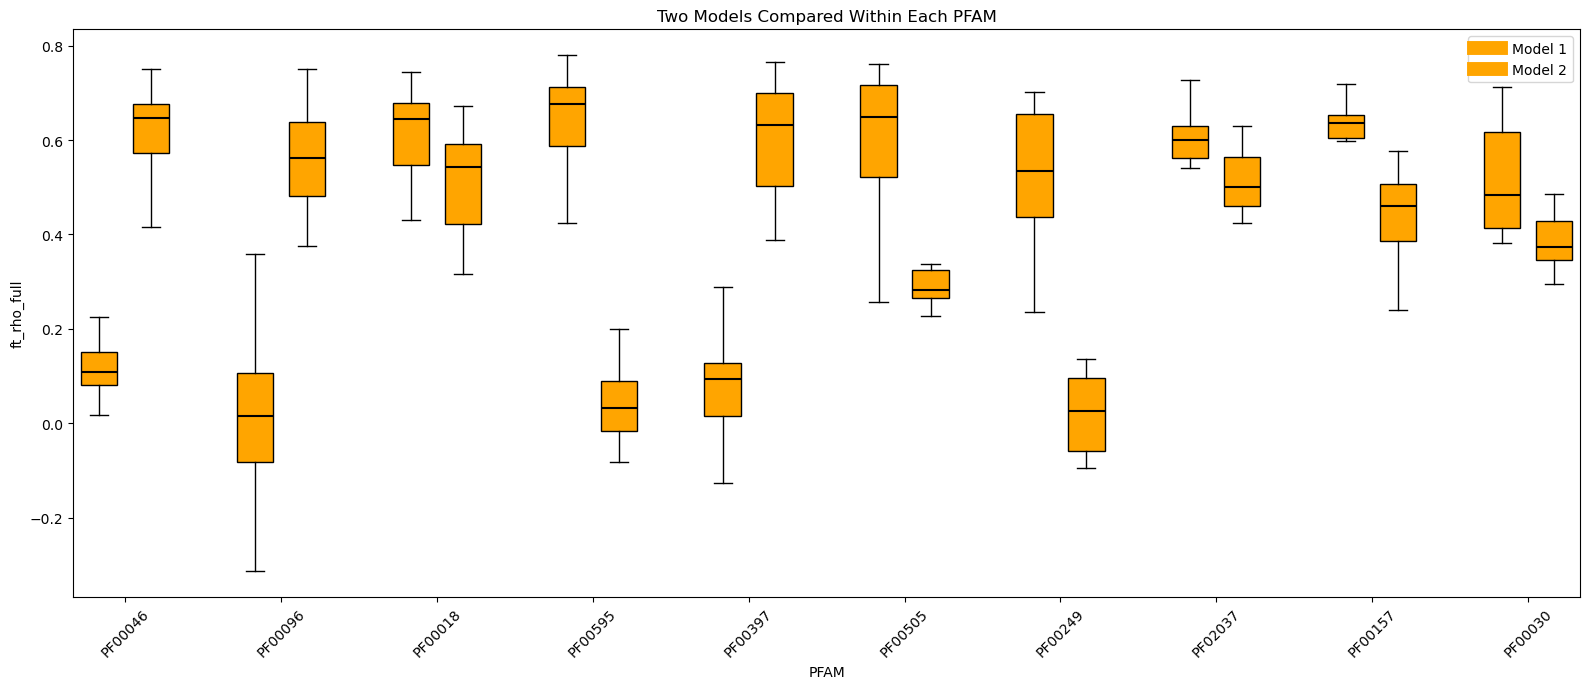

In [23]:
pfams = (
    df_best_worst["target_pfam"]
    .value_counts()
    .head(10)
    .index
)

fig, ax = plt.subplots(figsize=(16, 7))

positions = []
data = []
colors = []

group_centers = []
group_labels = []

x = 0

medianprops = dict(color='black', linewidth=1.5)

for pfam in pfams:

    sub = df_best_worst[df_best_worst["target_pfam"] == pfam]

    models = sub["model_domain"].unique()

    pfam_positions = []

    for i, model in enumerate(models):

        vals = sub.loc[
            sub["model_domain"] == model,
            "ft_rho_full"
        ].dropna()

        pos = x + i

        data.append(vals)
        positions.append(pos)
        pfam_positions.append(pos)

        colors.append(["orange", "orange"][i % 2])

    # center label between the two boxes
    group_centers.append(np.mean(pfam_positions))
    group_labels.append(pfam)

    x += 3  # gap between PFAM groups

# boxplots
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.7,
    patch_artist=True,
    showfliers=False,
    medianprops=medianprops
)

# colors
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

# x-axis now labeled by PFAM
ax.set_xticks(group_centers)
ax.set_xticklabels(group_labels, rotation=45)

ax.set_ylabel("ft_rho_full")
ax.set_xlabel("PFAM")
ax.set_title("Two Models Compared Within Each PFAM")

# legend
ax.plot([], [], color="orange", linewidth=10, label="Model 1")
ax.plot([], [], color="orange", linewidth=10, label="Model 2")
ax.legend()

plt.tight_layout()
plt.show()

In [24]:
df_base = df_valid[df_valid['model'] == df_valid['pfam']]
df_ft_all = df_valid[df_valid['model'] == 'all_pfams']
df_ft_pfam = df_valid[df_valid['model'] == df_valid['pfam']]

# First 10 PFAMs by number of domains

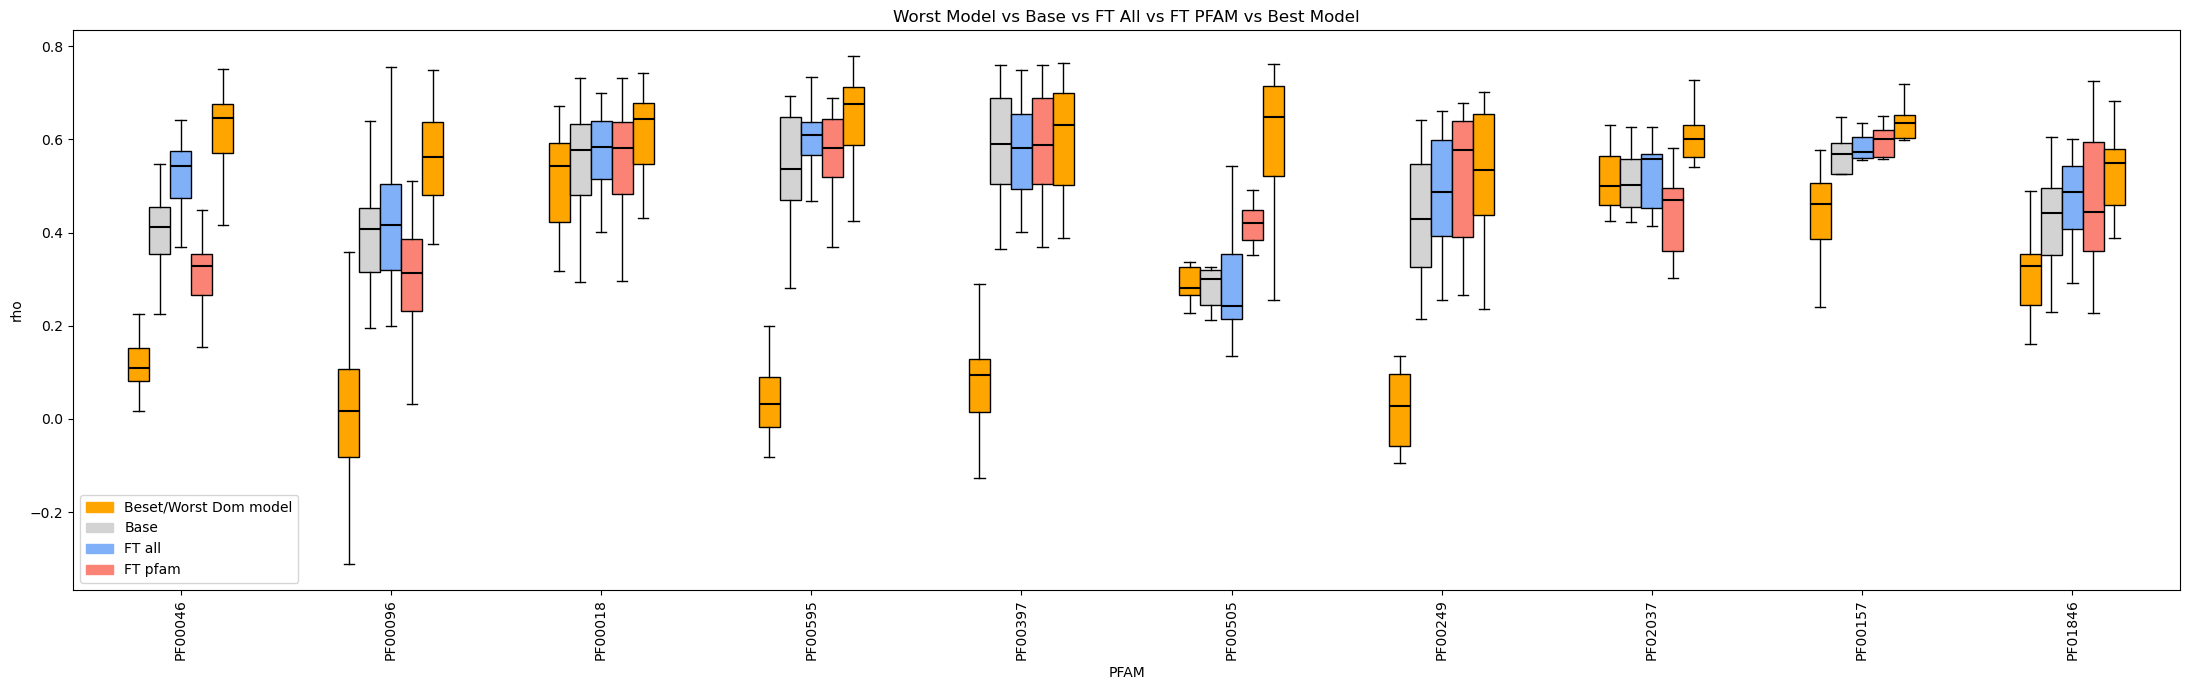

In [32]:
# pfam_order = df_valid['pfam'].value_counts().head(10).index
pfam_order = pfam_counts['pfam'].head(10)

spacing = 1.6
x = np.arange(len(pfam_order))*spacing
width = 0.16

# colors
worst_model_color = "steelblue"
best_model_color = "orange"

base_color = 'lightgray'
ft_all_color = "#80b0f8"
ft_pfam_color = "#fa8376"

fig, ax = plt.subplots(figsize=(22, 7))

medianprops = dict(color='black', linewidth=1.5)

# ---------------------------------------------------
# Main model distributions
# ---------------------------------------------------

base_data = [
    df_base[df_base['pfam'] == p]['rho_base']
    for p in pfam_order
]

ft_all_data = [
    df_ft_all[df_ft_all['pfam'] == p]['rho_ft']
    for p in pfam_order
]

ft_pfam_data = [
    df_ft_pfam[df_ft_pfam['pfam'] == p]['rho_ft']
    for p in pfam_order
]

# ---------------------------------------------------
# PFAM-specific best/worst models
# ---------------------------------------------------

worst_model_data = []
best_model_data = []

for pfam in pfam_order:

    sub = df_best_worst[df_best_worst["target_pfam"] == pfam]

    # median performance per model
    model_medians = (
        sub.groupby("model_domain")["ft_rho_full"]
        .median()
        .sort_values()
    )

    worst_model = model_medians.index[0]
    best_model = model_medians.index[-1]

    worst_vals = sub.loc[
        sub["model_domain"] == worst_model,
        "ft_rho_full"
    ].dropna()

    best_vals = sub.loc[
        sub["model_domain"] == best_model,
        "ft_rho_full"
    ].dropna()

    worst_model_data.append(worst_vals)
    best_model_data.append(best_vals)

# ---------------------------------------------------
# Plot order:
# worst | base | ft_all | ft_pfam | best
# ---------------------------------------------------

ax.boxplot(
    worst_model_data,
    positions=x - 2 * width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=best_model_color),
    medianprops=medianprops
)

ax.boxplot(
    base_data,
    positions=x - width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=base_color),
    medianprops=medianprops
)

ax.boxplot(
    ft_all_data,
    positions=x,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=ft_all_color),
    medianprops=medianprops
)

ax.boxplot(
    ft_pfam_data,
    positions=x + width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=ft_pfam_color),
    medianprops=medianprops
)

ax.boxplot(
    best_model_data,
    positions=x + 2 * width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=best_model_color),
    medianprops=medianprops
)

# ---------------------------------------------------
# Labels
# ---------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels(pfam_order, rotation=90)

ax.set_xlabel("PFAM")
ax.set_ylabel("rho")
ax.set_title("Worst Model vs Base vs FT All vs FT PFAM vs Best Model")

# legend
legend_handles = [
    mpatches.Patch(color=best_model_color, label='Beset/Worst Dom model'),
    mpatches.Patch(color=base_color, label='Base'),
    mpatches.Patch(color=ft_all_color, label='FT all'),
    mpatches.Patch(color=ft_pfam_color, label='FT pfam'),
    # mpatches.Patch(color=worst_model_color, label='Best PFAM model')
]

ax.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

In [29]:
pfam_counts[0:10]

,pfam,count
0,PF00046,37
1,PF00096,36
2,PF00018,36
3,PF00595,31
4,PF00397,26
5,PF00505,17
6,PF00249,15
7,PF02037,14
8,PF00157,12
9,PF01846,12


# 11-20 PFAMs by number of domains

In [38]:
pfam_counts['pfam'].iloc[10:20]

10    PF00030
11    PF00628
12    PF00105
13    PF00641
14    PF00313
15    PF00643
16    PF00013
17    PF00642
18    PF00412
19    PF06467
Name: pfam, dtype: object

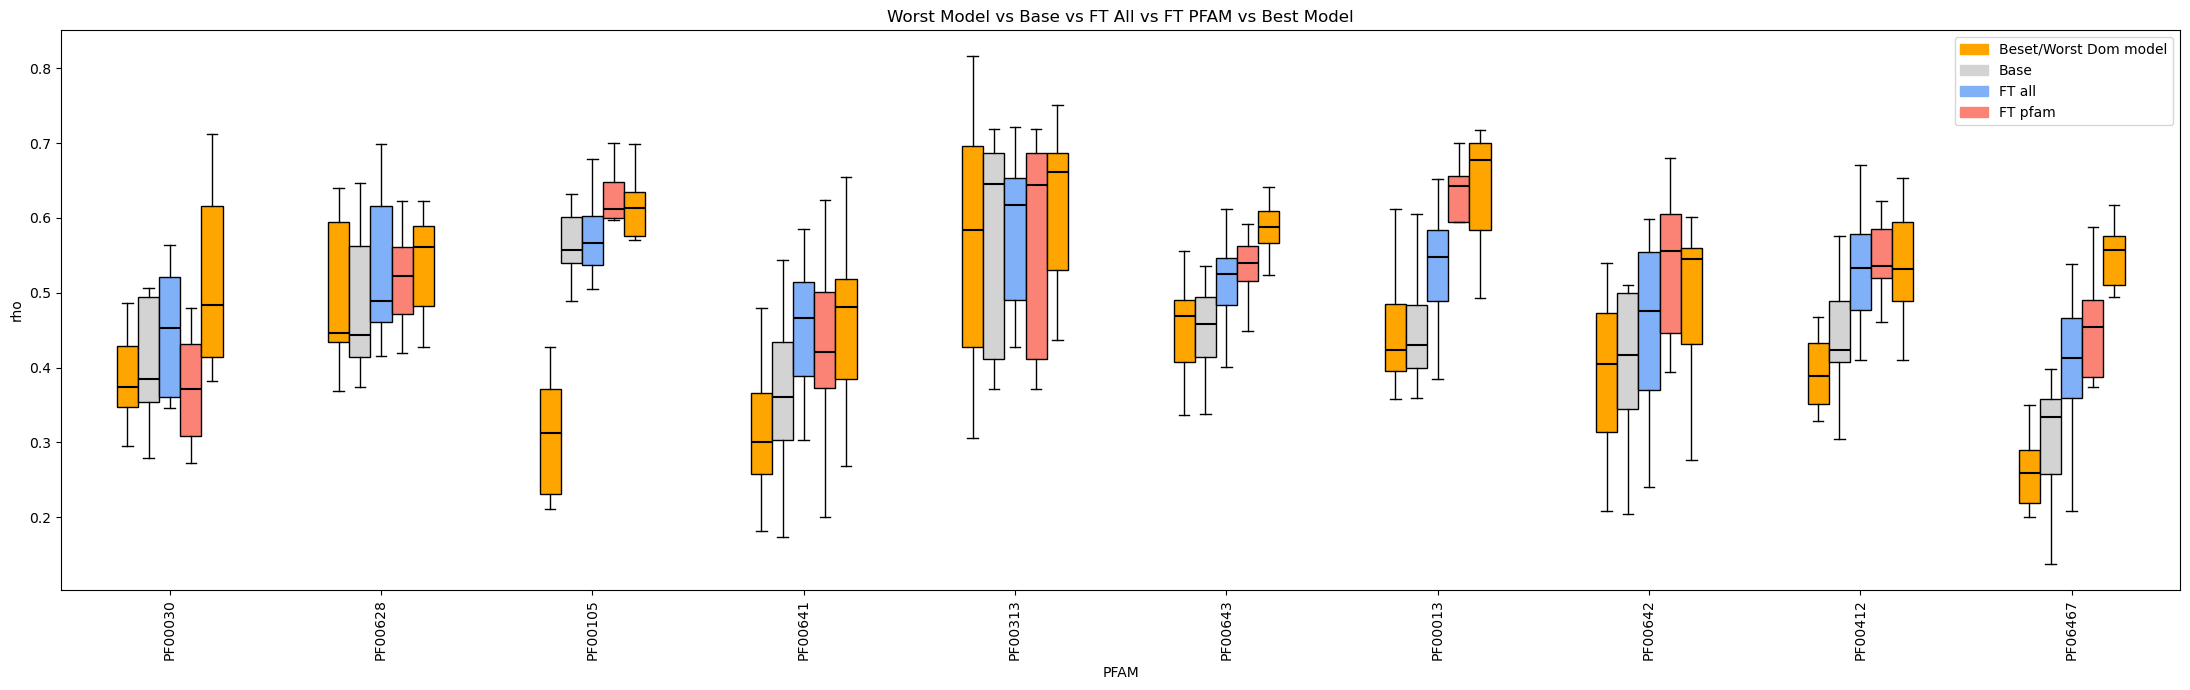

In [39]:
# pfam_order = df_valid['pfam'].value_counts().index[10:20]
pfam_order = pfam_counts['pfam'].iloc[10:20]

spacing = 1.6
x = np.arange(len(pfam_order))*spacing
width = 0.16

# colors
worst_model_color = "steelblue"
best_model_color = "orange"

base_color = 'lightgray'
ft_all_color = "#80b0f8"
ft_pfam_color = "#fa8376"

fig, ax = plt.subplots(figsize=(22, 7))

medianprops = dict(color='black', linewidth=1.5)

# ---------------------------------------------------
# Main model distributions
# ---------------------------------------------------

base_data = [
    df_base[df_base['pfam'] == p]['rho_base']
    for p in pfam_order
]

ft_all_data = [
    df_ft_all[df_ft_all['pfam'] == p]['rho_ft']
    for p in pfam_order
]

ft_pfam_data = [
    df_ft_pfam[df_ft_pfam['pfam'] == p]['rho_ft']
    for p in pfam_order
]

# ---------------------------------------------------
# PFAM-specific best/worst models
# ---------------------------------------------------

worst_model_data = []
best_model_data = []

for pfam in pfam_order:

    sub = df_best_worst[df_best_worst["target_pfam"] == pfam]

    # median performance per model
    model_medians = (
        sub.groupby("model_domain")["ft_rho_full"]
        .median()
        .sort_values()
    )

    worst_model = model_medians.index[0]
    best_model = model_medians.index[-1]

    worst_vals = sub.loc[
        sub["model_domain"] == worst_model,
        "ft_rho_full"
    ].dropna()

    best_vals = sub.loc[
        sub["model_domain"] == best_model,
        "ft_rho_full"
    ].dropna()

    worst_model_data.append(worst_vals)
    best_model_data.append(best_vals)

# ---------------------------------------------------
# Plot order:
# worst | base | ft_all | ft_pfam | best
# ---------------------------------------------------

ax.boxplot(
    worst_model_data,
    positions=x - 2 * width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=best_model_color),
    medianprops=medianprops
)

ax.boxplot(
    base_data,
    positions=x - width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=base_color),
    medianprops=medianprops
)

ax.boxplot(
    ft_all_data,
    positions=x,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=ft_all_color),
    medianprops=medianprops
)

ax.boxplot(
    ft_pfam_data,
    positions=x + width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=ft_pfam_color),
    medianprops=medianprops
)

ax.boxplot(
    best_model_data,
    positions=x + 2 * width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=best_model_color),
    medianprops=medianprops
)

# ---------------------------------------------------
# Labels
# ---------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels(pfam_order, rotation=90)

ax.set_xlabel("PFAM")
ax.set_ylabel("rho")
ax.set_title("Worst Model vs Base vs FT All vs FT PFAM vs Best Model")

# legend
legend_handles = [
    mpatches.Patch(color=best_model_color, label='Beset/Worst Dom model'),
    mpatches.Patch(color=base_color, label='Base'),
    mpatches.Patch(color=ft_all_color, label='FT all'),
    mpatches.Patch(color=ft_pfam_color, label='FT pfam'),
    # mpatches.Patch(color=worst_model_color, label='Best PFAM model')
]

ax.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

In [30]:
pfam_counts[10:20]

,pfam,count
10,PF00030,12
11,PF00628,11
12,PF00105,10
13,PF00641,10
14,PF00313,9
15,PF00643,9
16,PF00013,9
17,PF00642,8
18,PF00412,8
19,PF06467,8


In [41]:
pfam_counts['pfam'].iloc[20:30]

20     PF02376
21     PF14604
22     PF00627
23     PF02198
24     PF00226
25     PF13499
26     PF00536
27     PF07647
28     PF02209
29    rockdoms
Name: pfam, dtype: object

PF02376
PF14604
PF00627
PF02198
PF00226
PF13499
PF00536
PF07647


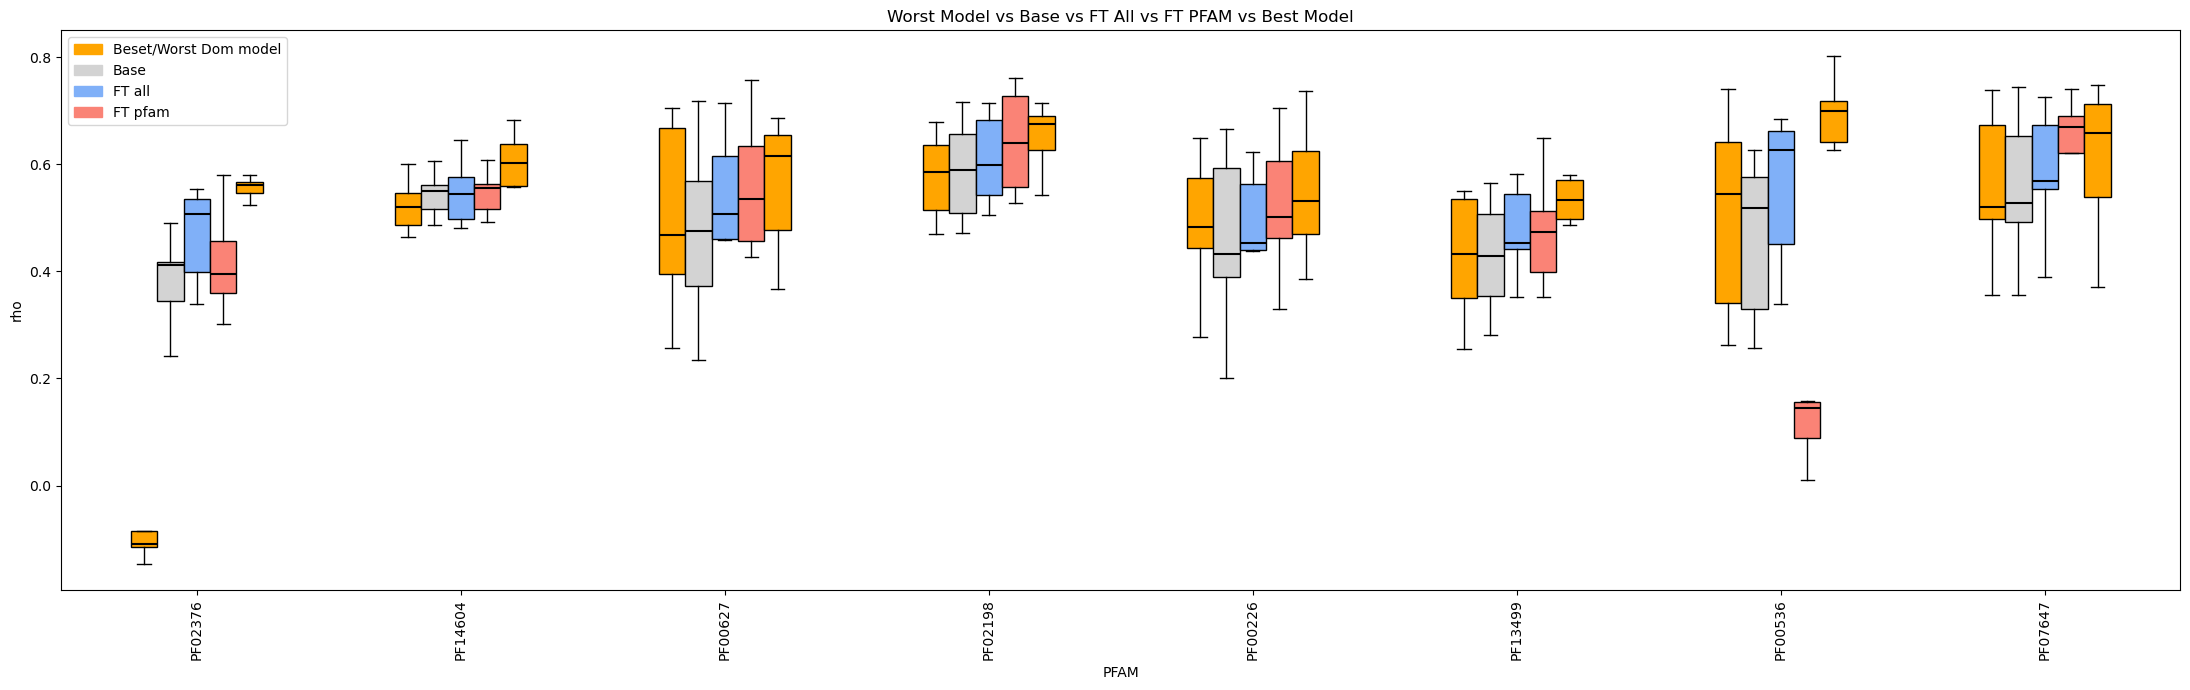

In [46]:
# pfam_order = df_valid['pfam'].value_counts().index[20:30]
pfam_order = pfam_counts['pfam'].iloc[20:28]

spacing = 1.6
x = np.arange(len(pfam_order))*spacing
width = 0.16

# colors
worst_model_color = "steelblue"
best_model_color = "orange"

base_color = 'lightgray'
ft_all_color = "#80b0f8"
ft_pfam_color = "#fa8376"

fig, ax = plt.subplots(figsize=(22, 7))
medianprops = dict(color='black', linewidth=1.5)

# ---------------------------------------------------
# Main model distributions
# ---------------------------------------------------

base_data = [
    df_base[df_base['pfam'] == p]['rho_base']
    for p in pfam_order
]

ft_all_data = [
    df_ft_all[df_ft_all['pfam'] == p]['rho_ft']
    for p in pfam_order
]

ft_pfam_data = [
    df_ft_pfam[df_ft_pfam['pfam'] == p]['rho_ft']
    for p in pfam_order
]

# ---------------------------------------------------
# PFAM-specific best/worst models
# ---------------------------------------------------

# worst_model_data = []
# best_model_data = []

# for pfam in pfam_order:
#     print(pfam)

#     sub = df_best_worst[df_best_worst["target_pfam"] == pfam]

#     # no entries for this PFAM
#     if sub.empty:
#         worst_model_data.append([np.nan])
#         best_model_data.append([np.nan])
#         continue

#     # median performance per model
#     model_medians = (
#         sub.groupby("model_domain")["ft_rho_full"]
#         .median()
#         .sort_values()
#     )

#     worst_model = model_medians.index[0]
#     best_model = model_medians.index[-1]

#     worst_vals = sub.loc[
#         sub["model_domain"] == worst_model,
#         "ft_rho_full"
#     ].dropna()

#     best_vals = sub.loc[
#         sub["model_domain"] == best_model,
#         "ft_rho_full"
#     ].dropna()

#     # if somehow empty after dropna
#     if len(worst_vals) == 0:
#         worst_vals = [np.nan]

#     if len(best_vals) == 0:
#         best_vals = [np.nan]

#     worst_model_data.append(worst_vals)
#     best_model_data.append(best_vals)

worst_model_data = []
best_model_data = []

for pfam in pfam_order:
    print(pfam)
    sub = df_best_worst[df_best_worst["target_pfam"] == pfam]

    # median performance per model
    model_medians = (
        sub.groupby("model_domain")["ft_rho_full"]
        .median()
        .sort_values()
    )

    worst_model = model_medians.index[0]
    best_model = model_medians.index[-1]

    worst_vals = sub.loc[
        sub["model_domain"] == worst_model,
        "ft_rho_full"
    ].dropna()

    best_vals = sub.loc[
        sub["model_domain"] == best_model,
        "ft_rho_full"
    ].dropna()

    worst_model_data.append(worst_vals)
    best_model_data.append(best_vals)

# ---------------------------------------------------
# Plot order:
# worst | base | ft_all | ft_pfam | best
# ---------------------------------------------------

ax.boxplot(
    worst_model_data,
    positions=x - 2 * width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=best_model_color),
    medianprops=medianprops
)

ax.boxplot(
    base_data,
    positions=x - width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=base_color),
    medianprops=medianprops
)

ax.boxplot(
    ft_all_data,
    positions=x,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=ft_all_color),
    medianprops=medianprops
)

ax.boxplot(
    ft_pfam_data,
    positions=x + width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=ft_pfam_color),
    medianprops=medianprops
)

ax.boxplot(
    best_model_data,
    positions=x + 2 * width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=best_model_color),
    medianprops=medianprops
)

# ---------------------------------------------------
# Labels
# ---------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels(pfam_order, rotation=90)

ax.set_xlabel("PFAM")
ax.set_ylabel("rho")
ax.set_title("Worst Model vs Base vs FT All vs FT PFAM vs Best Model")

# legend
legend_handles = [
    mpatches.Patch(color=best_model_color, label='Beset/Worst Dom model'),
    mpatches.Patch(color=base_color, label='Base'),
    mpatches.Patch(color=ft_all_color, label='FT all'),
    mpatches.Patch(color=ft_pfam_color, label='FT pfam'),
    # mpatches.Patch(color=worst_model_color, label='Best PFAM model')
]

ax.legend(handles=legend_handles)

plt.tight_layout()
plt.show()

In [28]:
pfam_counts.head(30)

,pfam,count
0,PF00046,37
1,PF00096,36
2,PF00018,36
3,PF00595,31
4,PF00397,26
5,PF00505,17
6,PF00249,15
7,PF02037,14
8,PF00157,12
9,PF01846,12


In [31]:
df_valid['pfam'].value_counts()

pfam
PF00046    4699
PF00018    4572
PF00096    4572
PF00595    3937
PF00397    3302
PF00505    2159
PF00249    1905
PF02037    1778
PF00030    1524
PF01846    1524
PF00157    1524
PF00628    1397
PF00641    1270
PF00105    1270
PF00313    1143
PF00643    1143
PF00013    1143
PF06467    1016
PF00642    1016
PF00412    1016
PF02376    1016
PF14604    1016
PF00627     889
PF13499     762
PF02198     762
PF00226     762
PF00536     762
PF07647     635
Name: count, dtype: int64

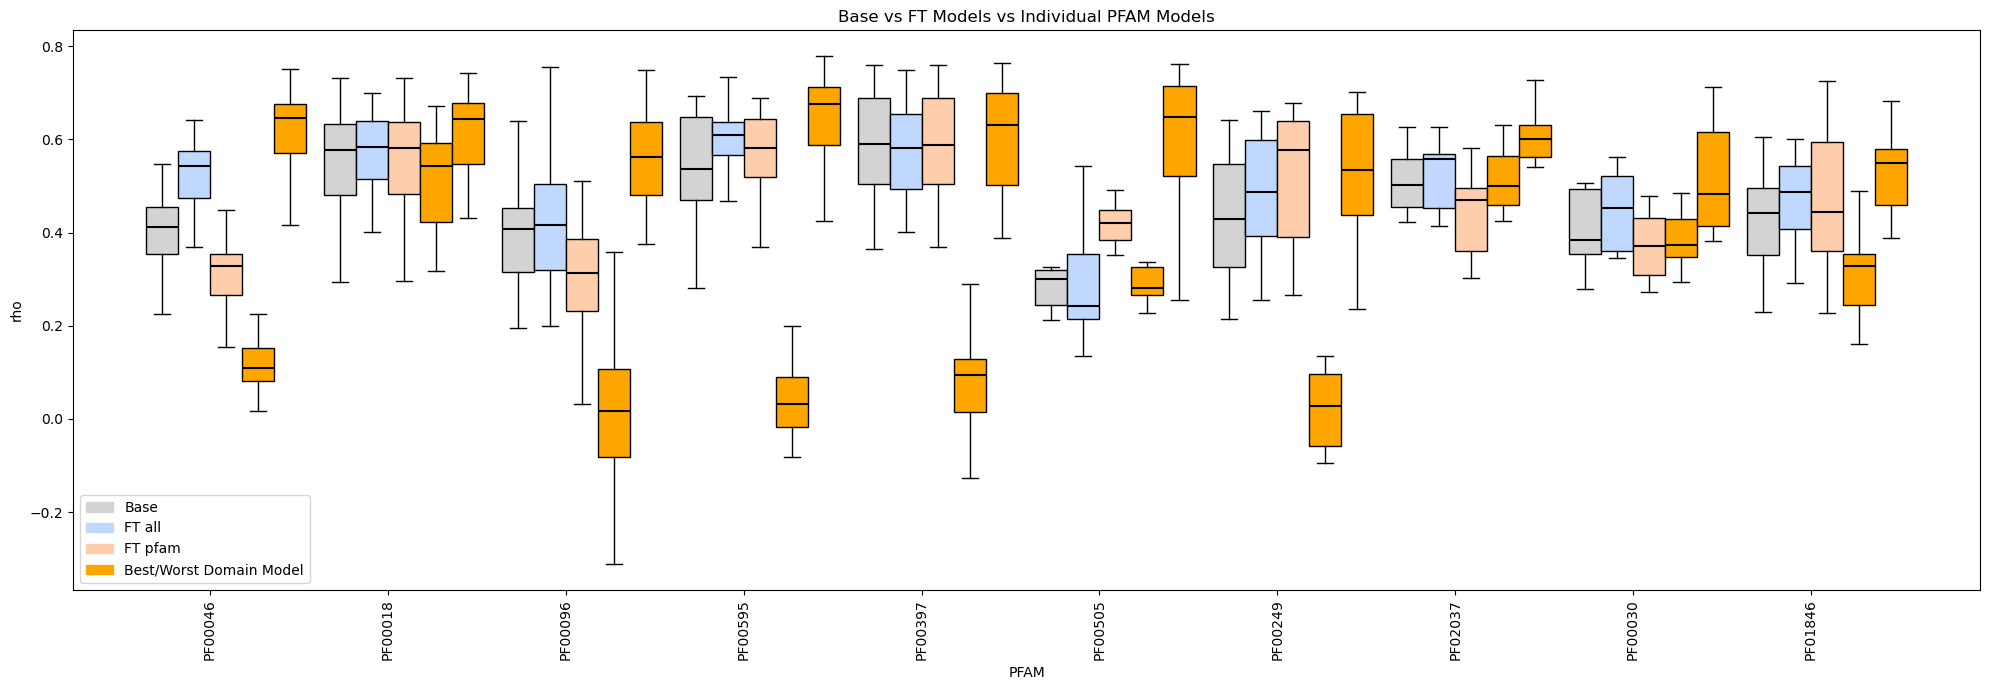

In [37]:
# make a new dataframe with best domain only, worst domain only, pfam, and base for top 10 pfams by number of doms
pfam_order = df_valid['pfam'].value_counts().head(10).index

x = np.arange(len(pfam_order))

# widths
width = 0.18

# colors
base_color = 'lightgray'
ft_all_color = "#c0d8fd"
ft_pfam_color = "#fecdac"

model_colors = ["orange", "orange"]

fig, ax = plt.subplots(figsize=(20, 7))

medianprops = dict(color='black', linewidth=1.5)

# ---------------------------------------------------
# Main three boxplots
# ---------------------------------------------------

base_data = [
    df_base[df_base['pfam'] == p]['rho_base']
    for p in pfam_order
]

ft_all_data = [
    df_ft_all[df_ft_all['pfam'] == p]['rho_ft']
    for p in pfam_order
]

ft_pfam_data = [
    df_ft_pfam[df_ft_pfam['pfam'] == p]['rho_ft']
    for p in pfam_order
]

# base
ax.boxplot(
    base_data,
    positions=x - 1.5 * width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=base_color),
    medianprops=medianprops
)

# ft all
ax.boxplot(
    ft_all_data,
    positions=x - 0.5 * width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=ft_all_color),
    medianprops=medianprops
)

# ft pfam
ax.boxplot(
    ft_pfam_data,
    positions=x + 0.5 * width,
    widths=width,
    patch_artist=True,
    showfliers=False,
    boxprops=dict(facecolor=ft_pfam_color),
    medianprops=medianprops
)

# ---------------------------------------------------
# Add two PFAM-specific model boxplots
# ---------------------------------------------------

# ---------------------------------------------------
# Add two PFAM-specific model boxplots
# ordered by median ft_rho_full
# ---------------------------------------------------

model_data = []
model_positions = []
model_box_colors = []

for i, pfam in enumerate(pfam_order):

    sub = df_best_worst[df_best_worst["target_pfam"] == pfam]

    # compute median performance for each model
    model_medians = (
        sub.groupby("model_domain")["ft_rho_full"]
        .median()
        .sort_values()   # lowest first
    )

    ordered_models = model_medians.index.tolist()

    for j, model in enumerate(ordered_models):

        vals = sub.loc[
            sub["model_domain"] == model,
            "ft_rho_full"
        ].dropna()

        model_data.append(vals)

        # positions to right of original 3 boxes
        model_positions.append(i + 1.5 * width + j * width)

        # lower median = blue, higher median = orange
        model_box_colors.append(model_colors[j])

bp_models = ax.boxplot(
    model_data,
    positions=model_positions,
    widths=width,
    patch_artist=True,
    showfliers=False,
    medianprops=medianprops
)

for patch, color in zip(bp_models['boxes'], model_box_colors):
    patch.set_facecolor(color)

# model_data = []
# model_positions = []
# model_box_colors = []

# for i, pfam in enumerate(pfam_order):

#     sub = df_best_worst[df_best_worst["target_pfam"] == pfam]

#     models = sub["model_domain"].unique()[:2]

#     for j, model in enumerate(models):

#         vals = sub.loc[
#             sub["model_domain"] == model,
#             "ft_rho_full"
#         ].dropna()

#         model_data.append(vals)

#         # place to right of original 3 boxes
#         model_positions.append(i + 1.5 * width + j * width)

#         model_box_colors.append(model_colors[j])

# bp_models = ax.boxplot(
#     model_data,
#     positions=model_positions,
#     widths=width,
#     patch_artist=True,
#     showfliers=False,
#     medianprops=medianprops
# )

# for patch, color in zip(bp_models['boxes'], model_box_colors):
#     patch.set_facecolor(color)

# ---------------------------------------------------
# Labels
# ---------------------------------------------------

ax.set_xticks(x)
ax.set_xticklabels(pfam_order, rotation=90)

ax.set_xlabel("PFAM")
ax.set_ylabel("rho")
ax.set_title("Base vs FT Models vs Individual PFAM Models")

# legend
legend_handles = [
    mpatches.Patch(color=base_color, label='Base'),
    mpatches.Patch(color=ft_all_color, label='FT all'),
    mpatches.Patch(color=ft_pfam_color, label='FT pfam'),
    mpatches.Patch(color='orange', label='Best/Worst Domain Model'),
    # mpatches.Patch(color='orange', label='PFAM model 2')
]

ax.legend(handles=legend_handles)

plt.tight_layout()
plt.show()


# Base vs all vs pfams

In [53]:
df_base = df_valid[df_valid['model'] == df_valid['pfam']]
df_ft_all = df_valid[df_valid['model'] == 'all_pfams']
df_ft_pfam = df_valid[df_valid['model'] == df_valid['pfam']]

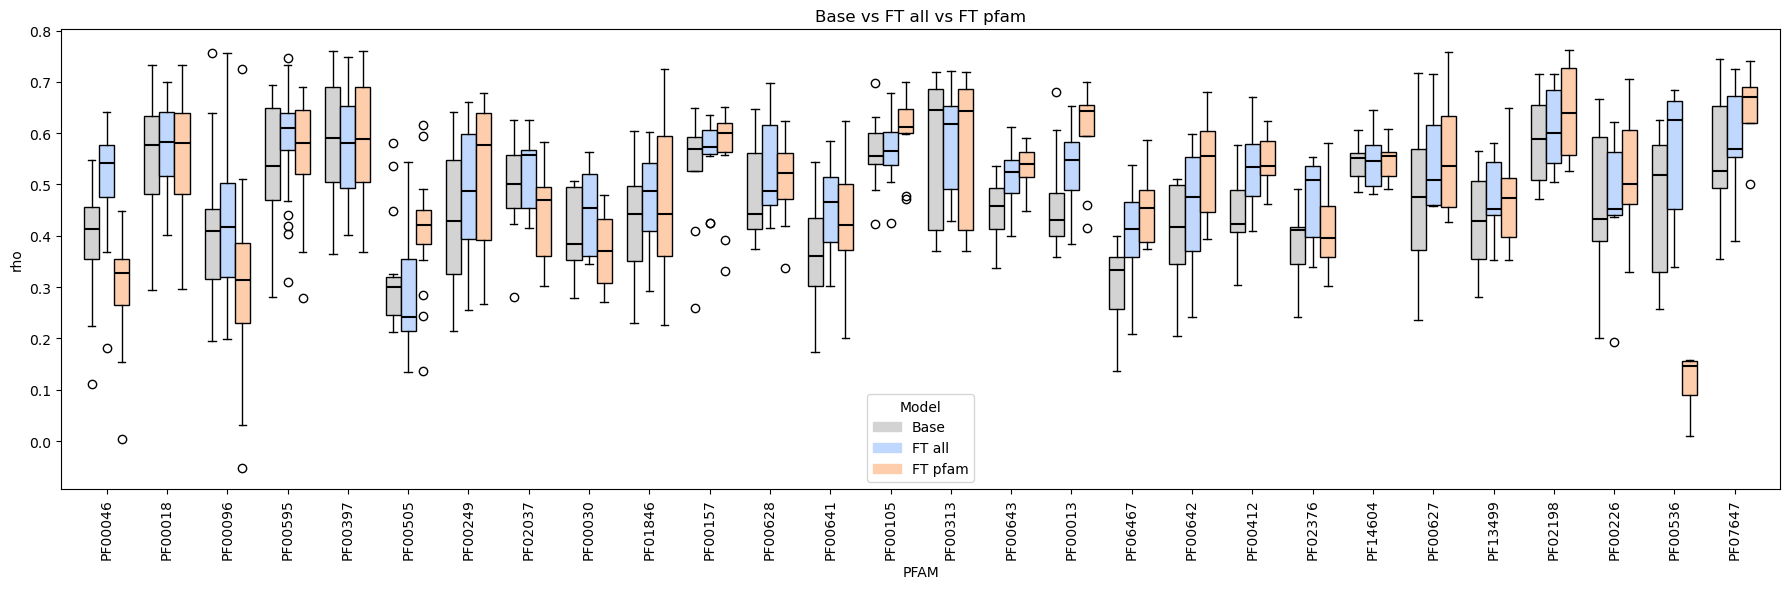

In [60]:
pfam_order = df_valid['pfam'].value_counts().index

x = np.arange(len(pfam_order))
width = 0.25

base_color = 'lightgray'
ft_all_color = "#c0d8fd"
ft_pfam_color = "#fecdac"

base_data = [df_base[df_base['pfam'] == p]['rho_base'] for p in pfam_order]

ft_all_data = [
    df_ft_all[df_ft_all['pfam'] == p]['rho_ft'] for p in pfam_order
]

ft_pfam_data = [
    df_ft_pfam[df_ft_pfam['pfam'] == p]['rho_ft'] for p in pfam_order
]

fig, ax = plt.subplots(figsize=(18, 6))

medianprops = dict(color='black', linewidth=1.5)

# base
ax.boxplot(
    base_data,
    positions=x - width,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor=base_color),
    medianprops=medianprops
)

# ft all
ax.boxplot(
    ft_all_data,
    positions=x,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor=ft_all_color),
    medianprops=medianprops
)

# ft pfam
ax.boxplot(
    ft_pfam_data,
    positions=x + width,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor=ft_pfam_color),
    medianprops=medianprops
)


ax.set_xticks(x)
ax.set_xticklabels(pfam_order, rotation=90)

ax.set_xlabel("PFAM")
ax.set_ylabel("rho")
ax.set_title("Base vs FT all vs FT pfam")

base_patch = mpatches.Patch(color=base_color, label='Base')
ft_all_patch = mpatches.Patch(color=ft_all_color, label='FT all')
ft_pfam_patch = mpatches.Patch(color=ft_pfam_color, label='FT pfam')

ax.legend(handles=[base_patch, ft_all_patch, ft_pfam_patch], title="Model")

plt.tight_layout()
plt.show()



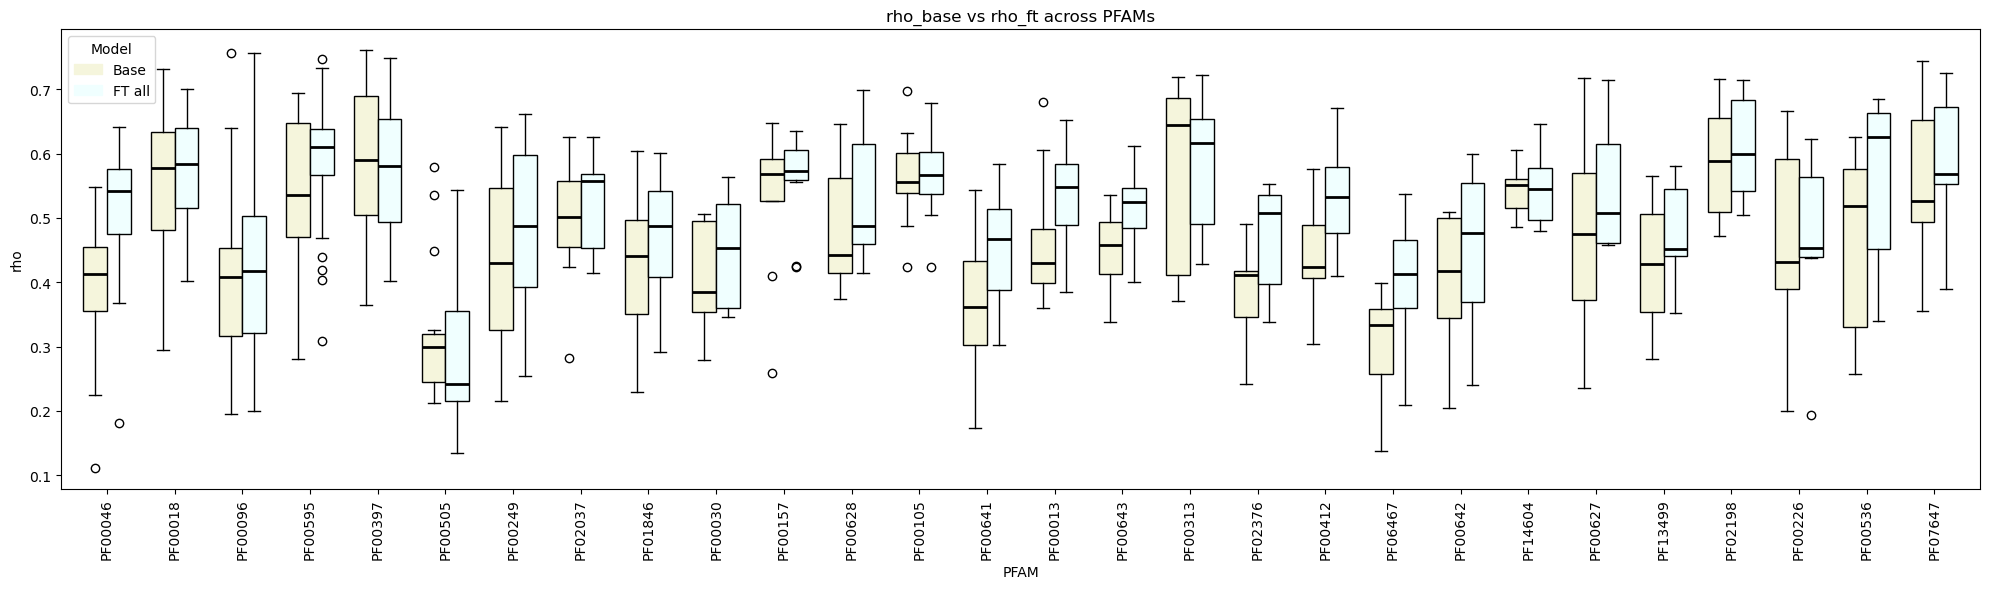

In [43]:
df_all = df_valid[df_valid['model'] == 'all_pfams']

pfam_order = df_all['pfam'].value_counts().index

# numeric x positions
x = np.arange(len(pfam_order))
width = 0.35
medianprops = dict(color='black', linewidth=2)

fig, ax = plt.subplots(figsize=(20, 6))

# data aligned to pfam order
base_data = [df_all[df_all['pfam'] == p]['rho_base'] for p in pfam_order]
ft_data   = [df_all[df_all['pfam'] == p]['rho_ft'] for p in pfam_order]

# boxplots with offsets
ax.boxplot(base_data, 
           positions=x - width/2, 
           widths=width, 
           patch_artist=True,
           boxprops=dict(facecolor='beige'),
           medianprops=medianprops)

ax.boxplot(ft_data,
           positions=x + width/2, 
           widths=width, 
           patch_artist=True,
           boxprops=dict(facecolor='azure'),
           medianprops=medianprops)

# labels
ax.set_xticks(x)
ax.set_xticklabels(pfam_order, rotation=90)

ax.set_xlabel("PFAM")
ax.set_ylabel("rho")
ax.set_title("rho_base vs rho_ft across PFAMs")

base_patch = mpatches.Patch(color='beige', label='Base')
ft_patch   = mpatches.Patch(color='azure', label='FT all')

ax.legend(handles=[base_patch, ft_patch], title="Model")

plt.tight_layout()
plt.show()

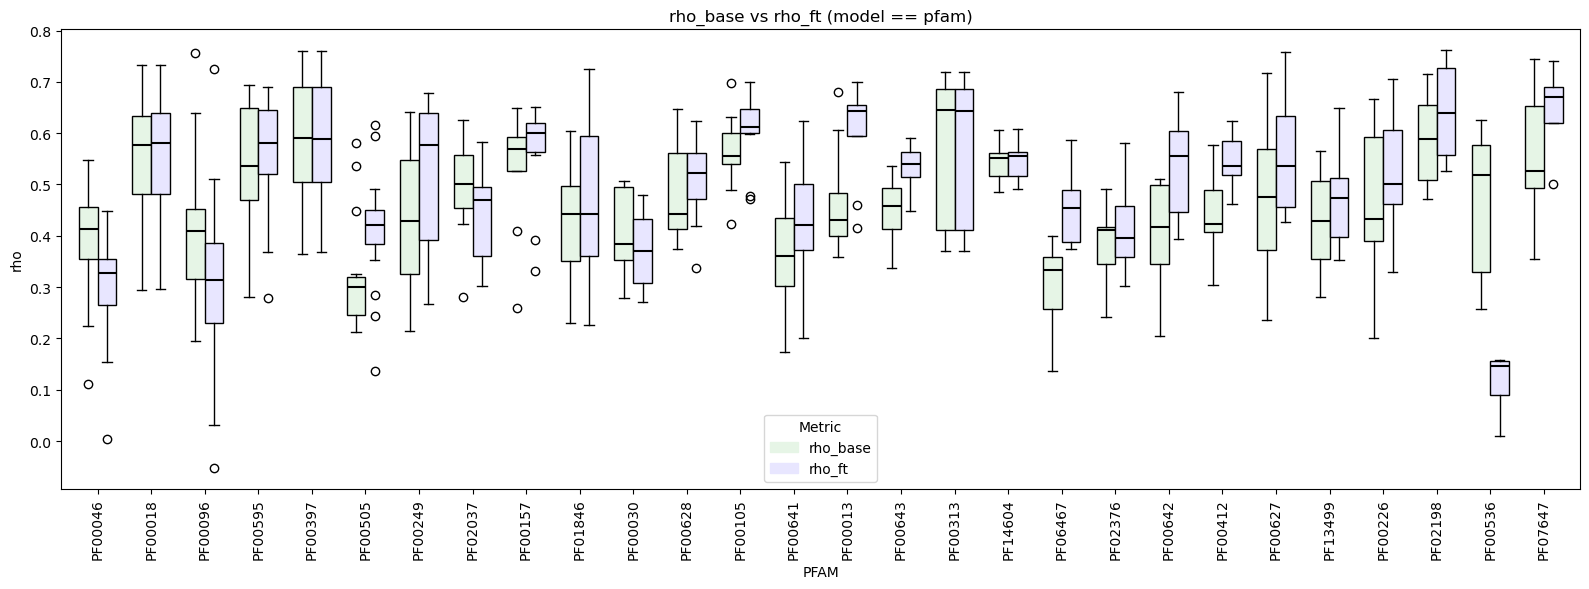

In [52]:

df_plot = df_valid[df_valid['model'] == df_valid['pfam']]

pfam_order = df_plot['pfam'].value_counts().index

x = np.arange(len(pfam_order))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))

# align data to pfam order
base_data = [df_plot[df_plot['pfam'] == p]['rho_base'] for p in pfam_order]
ft_data   = [df_plot[df_plot['pfam'] == p]['rho_ft'] for p in pfam_order]

medianprops = dict(color='black', linewidth=1.5)

# rho_base (left)
ax.boxplot(
    base_data,
    positions=x - width/2,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor='#e6f5e6'),
    medianprops=medianprops
)

# rho_ft (right)
ax.boxplot(
    ft_data,
    positions=x + width/2,
    widths=width,
    patch_artist=True,
    boxprops=dict(facecolor="#e8e6ff"),
    medianprops=medianprops
)

# axis labels
ax.set_xticks(x)
ax.set_xticklabels(pfam_order, rotation=90)

ax.set_xlabel("PFAM")
ax.set_ylabel("rho")
ax.set_title("rho_base vs rho_ft (model == pfam)")

# legend
import matplotlib.patches as mpatches

base_patch = mpatches.Patch(color='#e6f5e6', label='rho_base')
ft_patch   = mpatches.Patch(color="#e8e6ff", label='rho_ft')

ax.legend(handles=[base_patch, ft_patch], title="Metric")

plt.tight_layout()
plt.show()

In [46]:
df_plot = df_valid[
    (df_valid['model'] == df_valid['pfam'])
]

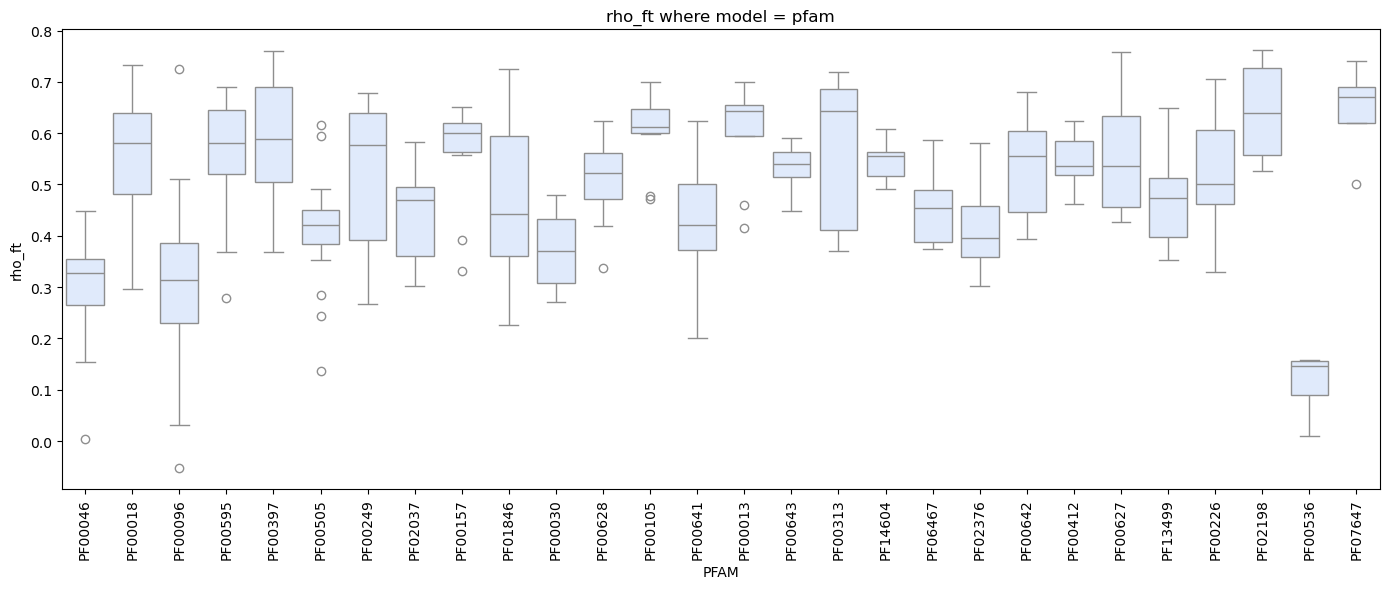

In [48]:
pfam_order = df_plot['pfam'].value_counts().index

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df_plot,
    x='pfam',
    y='rho_ft',
    order=pfam_order,
    color='#dbe9ff'
)

plt.xticks(rotation=90)
plt.xlabel("PFAM")
plt.ylabel("rho_ft")
plt.title("rho_ft where model = pfam")

plt.tight_layout()
plt.show()

# Make combined csv

In [ ]:
# load pfam data
datafile = "/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ESM2_ft_combined_sp_df.csv.gz"

with gzip.open(datafile, "rt") as f:
    df = pd.read_csv(f)

In [ ]:
# load all domain data
datafile = "/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ft_all_doms_run2_global_finetune_ESM2_ft_all_sp_df.csv.gz"

with gzip.open(datafile, "rt") as f:
    df_all = pd.read_csv(f)

In [13]:
df_all.head()

,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
0,Q9Y6N9_PF00595_207,Q9Y6N9,1255,0.378841,4.165029e-44,0.626113,1.456364e-137,0.247273,PF00595
1,P20936_PF00018_281,P20936,1158,0.422455,2.486852e-51,0.666934,6.875281e-150,0.244478,PF00018
2,Q86VP1_PF18112_729,Q86VP1,494,0.299746,1.029321e-11,0.531721,2.119634e-37,0.231975,PF18112
3,P22681_PF00627_854,P22681,850,0.235321,3.693812e-12,0.457588,3.250431e-45,0.222268,PF00627
4,Q9P0J7_PF05605_76,Q9P0J7,1093,0.303563,9.848891e-25,0.520061,9.076428e-77,0.216498,PF05605


In [ ]:
# counting domains in pfams

pfam_counts = (
    df_all['pfam']
    .value_counts()
    .reset_index()
)

pfam_counts.columns = ['pfam', 'count']

In [ ]:
# list of pfams with at least 5 domains
pfam_g4 = pfam_counts[pfam_counts['count']>4]['pfam']

In [21]:
df_comb = pd.concat([df, df_all])

In [26]:
df_comb.head()

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
0,PF00010,Q7Z6G8_PF00536_812,Q7Z6G8,False,1143,0.257597,8.820103e-19,0.787307,6.918559e-242,0.529710,PF00536
1,PF11722,Q9NUP7_PF11722_18,Q9NUP7,True,439,0.026799,5.754848e-01,0.539265,1.734913e-34,0.512467,PF11722
2,PF00010,Q8WU90_PF18044_104,Q8WU90,False,397,0.166906,8.422100e-04,0.626052,1.362520e-44,0.459146,PF18044
3,PF00569,Q9Y4J8_PF00569_235,Q9Y4J8,True,1119,0.188510,2.071464e-10,0.629437,1.623944e-124,0.440927,PF00569
4,PF02209,P09327_PF02209_793,P09327,True,632,0.186976,2.212267e-06,0.618647,5.136239e-68,0.431671,PF02209


In [24]:
df_comb['model'] = df_comb['model'].fillna('all_pfams')

In [27]:
df_comb.to_csv("/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ft_all_pfam_sp.csv.gz", index=False, compression='gzip')

# Sanity checks

In [12]:
df_all[df_all['domain_id']=='Q9NUP7_PF11722_18']

,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
247,Q9NUP7_PF11722_18,Q9NUP7,439,0.026799,0.575485,0.064433,0.177798,0.037634,PF11722


In [11]:
df[df['domain_id']=='Q9NUP7_PF11722_18']

,model,domain_id,uniprot_id,in_pfam_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
1,PF11722,Q9NUP7_PF11722_18,Q9NUP7,True,439,0.026799,0.575485,0.539265,1.734913e-34,0.512467,PF11722
27,PF02008,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,0.348148,5.916150e-14,0.321349,PF11722
203,PF01246,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,0.242614,2.662307e-07,0.215815,PF11722
241,PF18044,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,0.233943,7.173038e-07,0.207144,PF11722
439,PF06220,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,0.201727,2.058449e-05,0.174928,PF11722
...,...,...,...,...,...,...,...,...,...,...,...
59556,PF00787,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,-0.006317,8.950084e-01,-0.033115,PF11722
60700,PF09329,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,-0.022249,6.420053e-01,-0.049048,PF11722
60866,PF18366,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,-0.025644,5.920536e-01,-0.052443,PF11722
61522,PF07525,Q9NUP7_PF11722_18,Q9NUP7,False,439,0.026799,0.575485,-0.044627,3.509041e-01,-0.071426,PF11722


In [9]:
df['in_pfam_train'].unique()

array([False,  True])

In [5]:
df['model'].unique()

array(['PF00010', 'PF11722', 'PF00569', 'PF02209', 'PF02187', 'PF01246',
       'PF06467', 'PF10650', 'PF02008', 'PF18044', 'PF01429', 'PF02295',
       'PF00787', 'PF18112', 'PF09329', 'PF02207', 'PF00013', 'PF00412',
       'PF00533', 'PF05225', 'PF00567', 'PF00536', 'PF05715', 'PF13639',
       'PF02185', 'PF00096', 'PF00642', 'PF00240', 'PF00831', 'PF02037',
       'PF00320', 'PF12171', 'PF00619', 'PF00595', 'PF00458', 'PF06220',
       'PF11793', 'PF16557', 'PF00249', 'PF07647', 'PF00035', 'PF00280',
       'PF05605', 'PF08313', 'PF02270', 'PF17035', 'PF00627', 'PF00538',
       'PF01846', 'PF00778', 'PF01480', 'PF08073', 'PF02172', 'PF02376',
       'PF07525', 'PF01335', 'PF02845', 'PF14369', 'PF00505', 'PF01381',
       'PF13891', 'PF10264', 'PF00612', 'PF00130', 'PF03638', 'PF00046',
       'PF04855', 'PF02359', 'PF11515', 'PF18410', 'PF18366', 'PF00643',
       'PF02198', 'PF16558', 'PF02017', 'PF00385', 'PF02179', 'PF18694',
       'PF02196', 'PF00789', 'PF04433', 'PF12678', 